# BioOS Research Graph Demonstration

This notebook demonstrates how BioOS converts multiple scientific excerpts into a persistent research graph.

Unlike the extraction benchmark in `01-bioos_evaluation.ipynb`, the goal here is not to measure extraction accuracy. Instead, this notebook demonstrates the core BioOS workflow:

1. Import scientific text
2. Extract structured research objects
3. Identify relationships between objects
4. Accumulate knowledge across multiple excerpts
5. Inspect the resulting research graph

The example below simulates a researcher reading several related excerpts about PI3K/AKT signaling and targeted cancer therapy.

In [1]:
import requests
import pandas as pd
import time

API_BASE = "http://127.0.0.1:8000"
EXTRACT_URL = f"{API_BASE}/api/extract"

print("BioOS API:", API_BASE)

BioOS API: http://127.0.0.1:8000


In [2]:
excerpts = [
    {
        "id": "P01",
        "text": (
            "PIK3CA mutations are frequently observed in breast cancer. "
            "PIK3CA activates the PI3K-AKT signaling pathway."
        )
    },
    {
        "id": "P02",
        "text": (
            "Alpelisib targets PIK3CA and is used in patients with "
            "PIK3CA-mutated breast cancer."
        )
    },
    {
        "id": "P03",
        "text": (
            "AKT1 functions downstream of PI3K signaling and contributes "
            "to cancer cell proliferation."
        )
    },
    {
        "id": "P04",
        "text": (
            "The mTOR signaling pathway functions downstream of AKT "
            "and regulates cellular growth and metabolism."
        )
    },
    {
        "id": "P05",
        "text": (
            "PI3K-AKT-mTOR signaling is frequently dysregulated in cancer "
            "and represents an important therapeutic signaling axis."
        )
    }
]

pd.DataFrame(excerpts)

,id,text
0,P01,PIK3CA mutations are frequently observed in br...
1,P02,Alpelisib targets PIK3CA and is used in patien...
2,P03,AKT1 functions downstream of PI3K signaling an...
3,P04,The mTOR signaling pathway functions downstrea...
4,P05,PI3K-AKT-mTOR signaling is frequently dysregul...


## Sequential Knowledge Extraction

Each excerpt is processed independently through the BioOS extraction API.

The extracted objects and relationships are retained together with their source excerpt. In the following sections, these independent pieces of structured knowledge will be combined into a cumulative research graph.

In [3]:
extraction_results = []

for excerpt in excerpts:
    print(f"Processing {excerpt['id']}...", end=" ")

    start = time.time()

    try:
        response = requests.post(
            EXTRACT_URL,
            json={"text": excerpt["text"]},
            timeout=120
        )

        response.raise_for_status()
        data = response.json()

        latency = time.time() - start

        extraction_results.append({
            "id": excerpt["id"],
            "text": excerpt["text"],
            "title": data.get("title"),
            "objects": data.get("objects", []),
            "relationships": data.get("relationships", []),
            "latency_s": round(latency, 2),
            "error": None
        })

        print(
            f"{len(data.get('objects', []))} objects, "
            f"{len(data.get('relationships', []))} relationships "
            f"({latency:.2f}s)"
        )

    except Exception as e:
        extraction_results.append({
            "id": excerpt["id"],
            "text": excerpt["text"],
            "title": None,
            "objects": [],
            "relationships": [],
            "latency_s": None,
            "error": str(e)
        })

        print(f"ERROR: {e}")


extractions_df = pd.DataFrame(extraction_results)

extractions_df

Processing P01... 2 objects, 0 relationships (34.29s)
Processing P02... 2 objects, 1 relationships (24.36s)
Processing P03... 1 objects, 0 relationships (23.10s)
Processing P04... 1 objects, 0 relationships (19.62s)
Processing P05... 1 objects, 0 relationships (21.47s)


,id,text,title,objects,relationships,latency_s,error
0,P01,PIK3CA mutations are frequently observed in br...,PIK3CA Mutations and Signaling,"[{'tempId': 'o1', 'type': 'Gene', 'name': 'PIK...",[],34.29,None
1,P02,Alpelisib targets PIK3CA and is used in patien...,Alpelisib Targets PIK3CA in Breast Cancer,"[{'tempId': 'o1', 'type': 'Drug', 'name': 'Alp...","[{'from': 'o1', 'to': 'o2', 'type': 'TARGETS'}]",24.36,None
2,P03,AKT1 functions downstream of PI3K signaling an...,AKT1 Role in Cancer Cell Proliferation,"[{'tempId': 'o1', 'type': 'Gene', 'name': 'AKT...",[],23.10,None
3,P04,The mTOR signaling pathway functions downstrea...,mTOR Signaling Pathway Regulation,"[{'tempId': 'o1', 'type': 'Pathway', 'name': '...",[],19.62,None
4,P05,PI3K-AKT-mTOR signaling is frequently dysregul...,PI3K-AKT-mTOR Dysregulation in Cancer,"[{'tempId': 'o1', 'type': 'Pathway', 'name': '...",[],21.47,None


In [4]:
def summarize_objects(objects):
    return [
        f"{obj['name']} ({obj['type']})"
        for obj in objects
    ]


extractions_df["extracted_objects"] = (
    extractions_df["objects"].apply(summarize_objects)
)


extractions_df[
    [
        "id",
        "title",
        "extracted_objects",
        "latency_s",
        "error"
    ]
]

,id,title,extracted_objects,latency_s,error
0,P01,PIK3CA Mutations and Signaling,"[PIK3CA (Gene), PI3K-AKT signaling pathway (Pa...",34.29,None
1,P02,Alpelisib Targets PIK3CA in Breast Cancer,"[Alpelisib (Drug), PIK3CA (Gene)]",24.36,None
2,P03,AKT1 Role in Cancer Cell Proliferation,[AKT1 (Gene)],23.10,None
3,P04,mTOR Signaling Pathway Regulation,[mTOR signaling pathway (Pathway)],19.62,None
4,P05,PI3K-AKT-mTOR Dysregulation in Cancer,[PI3K-AKT-mTOR (Pathway)],21.47,None


In [5]:
def resolve_relationships(objects, relationships):
    id_to_object = {
        obj["tempId"]: obj
        for obj in objects
    }

    resolved = []

    for rel in relationships:
        source_obj = id_to_object.get(rel["from"])
        target_obj = id_to_object.get(rel["to"])

        if source_obj and target_obj:
            resolved.append({
                "source": source_obj["name"],
                "source_type": source_obj["type"],
                "relationship": rel["type"],
                "target": target_obj["name"],
                "target_type": target_obj["type"]
            })

    return resolved


extractions_df["resolved_relationships"] = (
    extractions_df.apply(
        lambda row: resolve_relationships(
            row["objects"],
            row["relationships"]
        ),
        axis=1
    )
)


extractions_df[
    ["id", "extracted_objects", "resolved_relationships"]
]

,id,extracted_objects,resolved_relationships
0,P01,"[PIK3CA (Gene), PI3K-AKT signaling pathway (Pa...",[]
1,P02,"[Alpelisib (Drug), PIK3CA (Gene)]","[{'source': 'Alpelisib', 'source_type': 'Drug'..."
2,P03,[AKT1 (Gene)],[]
3,P04,[mTOR signaling pathway (Pathway)],[]
4,P05,[PI3K-AKT-mTOR (Pathway)],[]


In [6]:
def normalize_name(name):
    return name.strip().lower()


cumulative_objects = {}

for _, row in extractions_df.iterrows():

    for obj in row["objects"]:

        key = (
            normalize_name(obj["name"]),
            obj["type"]
        )

        if key not in cumulative_objects:
            cumulative_objects[key] = {
                "name": obj["name"],
                "type": obj["type"],
                "summary": obj.get("summary", ""),
                "sources": [row["id"]],
                "mention_count": 1
            }

        else:
            cumulative_objects[key]["sources"].append(row["id"])
            cumulative_objects[key]["mention_count"] += 1


cumulative_objects_df = pd.DataFrame(
    cumulative_objects.values()
)

cumulative_objects_df

,name,type,summary,sources,mention_count
0,PIK3CA,Gene,Mutations in PIK3CA are commonly found in brea...,"[P01, P02]",2
1,PI3K-AKT signaling pathway,Pathway,This pathway is activated by PIK3CA mutations.,[P01],1
2,Alpelisib,Drug,An inhibitor used to treat patients with speci...,[P02],1
3,AKT1,Gene,AKT1 is a gene involved in cancer cell prolife...,[P03],1
4,mTOR signaling pathway,Pathway,A key pathway involved in regulating cellular ...,[P04],1
5,PI3K-AKT-mTOR,Pathway,The PI3K-AKT-mTOR signaling pathway is frequen...,[P05],1


In [7]:
growth_records = []

seen_objects = set()

for _, row in extractions_df.iterrows():

    new_objects = []
    reused_objects = []

    for obj in row["objects"]:

        key = (
            normalize_name(obj["name"]),
            obj["type"]
        )

        if key in seen_objects:
            reused_objects.append(obj["name"])
        else:
            new_objects.append(obj["name"])
            seen_objects.add(key)

    growth_records.append({
        "after_import": row["id"],
        "new_objects": new_objects,
        "reused_objects": reused_objects,
        "total_unique_objects": len(seen_objects)
    })


graph_growth_df = pd.DataFrame(growth_records)

graph_growth_df

,after_import,new_objects,reused_objects,total_unique_objects
0,P01,"[PIK3CA, PI3K-AKT signaling pathway]",[],2
1,P02,[Alpelisib],[PIK3CA],3
2,P03,[AKT1],[],4
3,P04,[mTOR signaling pathway],[],5
4,P05,[PI3K-AKT-mTOR],[],6


## Constructing the Cumulative Research Graph

The extracted objects can now be combined into a single persistent graph.

Objects with matching normalized names and types are represented by a
single node, while their source excerpts are retained as provenance.
Extracted relationships are converted from excerpt-specific temporary IDs
into relationships between the persistent research objects.

This allows information from separate imports to accumulate around shared
biomedical concepts.

In [8]:
# Create persistent graph nodes

graph_nodes = []

for i, obj in enumerate(cumulative_objects.values(), start=1):
    graph_nodes.append({
        "id": f"n{i}",
        "name": obj["name"],
        "type": obj["type"],
        "summary": obj["summary"],
        "sources": obj["sources"],
        "mention_count": obj["mention_count"]
    })


graph_nodes_df = pd.DataFrame(graph_nodes)

graph_nodes_df

,id,name,type,summary,sources,mention_count
0,n1,PIK3CA,Gene,Mutations in PIK3CA are commonly found in brea...,"[P01, P02]",2
1,n2,PI3K-AKT signaling pathway,Pathway,This pathway is activated by PIK3CA mutations.,[P01],1
2,n3,Alpelisib,Drug,An inhibitor used to treat patients with speci...,[P02],1
3,n4,AKT1,Gene,AKT1 is a gene involved in cancer cell prolife...,[P03],1
4,n5,mTOR signaling pathway,Pathway,A key pathway involved in regulating cellular ...,[P04],1
5,n6,PI3K-AKT-mTOR,Pathway,The PI3K-AKT-mTOR signaling pathway is frequen...,[P05],1


In [9]:
node_lookup = {
    (normalize_name(node["name"]), node["type"]): node["id"]
    for node in graph_nodes
}

node_lookup

{('pik3ca', 'Gene'): 'n1',
 ('pi3k-akt signaling pathway', 'Pathway'): 'n2',
 ('alpelisib', 'Drug'): 'n3',
 ('akt1', 'Gene'): 'n4',
 ('mtor signaling pathway', 'Pathway'): 'n5',
 ('pi3k-akt-mtor', 'Pathway'): 'n6'}

In [10]:
graph_edges = []

edge_counter = 1

for _, row in extractions_df.iterrows():

    for rel in row["resolved_relationships"]:

        source_key = (
            normalize_name(rel["source"]),
            rel["source_type"]
        )

        target_key = (
            normalize_name(rel["target"]),
            rel["target_type"]
        )

        source_id = node_lookup.get(source_key)
        target_id = node_lookup.get(target_key)

        if source_id and target_id:
            graph_edges.append({
                "id": f"e{edge_counter}",
                "source": source_id,
                "target": target_id,
                "relationship": rel["relationship"],
                "source_excerpt": row["id"]
            })

            edge_counter += 1


graph_edges_df = pd.DataFrame(graph_edges)

graph_edges_df

,id,source,target,relationship,source_excerpt
0,e1,n3,n1,TARGETS,P02


In [11]:
id_to_name = {
    node["id"]: node["name"]
    for node in graph_nodes
}


if not graph_edges_df.empty:
    readable_edges_df = graph_edges_df.copy()

    readable_edges_df["source_name"] = (
        readable_edges_df["source"].map(id_to_name)
    )

    readable_edges_df["target_name"] = (
        readable_edges_df["target"].map(id_to_name)
    )

    readable_edges_df = readable_edges_df[
        [
            "source_name",
            "relationship",
            "target_name",
            "source_excerpt"
        ]
    ]

else:
    readable_edges_df = pd.DataFrame(
        columns=[
            "source_name",
            "relationship",
            "target_name",
            "source_excerpt"
        ]
    )


readable_edges_df

,source_name,relationship,target_name,source_excerpt
0,Alpelisib,TARGETS,PIK3CA,P02


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

## Visualizing the Persistent Research Graph

The accumulated objects and relationships can be represented as a graph.
Each node corresponds to a unique biomedical research object, while edges
represent relationships extracted from the imported excerpts.

Repeated mentions are merged into the same persistent node. Source
provenance remains attached to both nodes and relationships.

In [13]:
G = nx.DiGraph()

# Add persistent research objects
for node in graph_nodes:
    G.add_node(
        node["id"],
        name=node["name"],
        type=node["type"],
        sources=node["sources"],
        mention_count=node["mention_count"]
    )

# Add extracted relationships
for edge in graph_edges:
    G.add_edge(
        edge["source"],
        edge["target"],
        relationship=edge["relationship"],
        source_excerpt=edge["source_excerpt"]
    )

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 6
Edges: 1


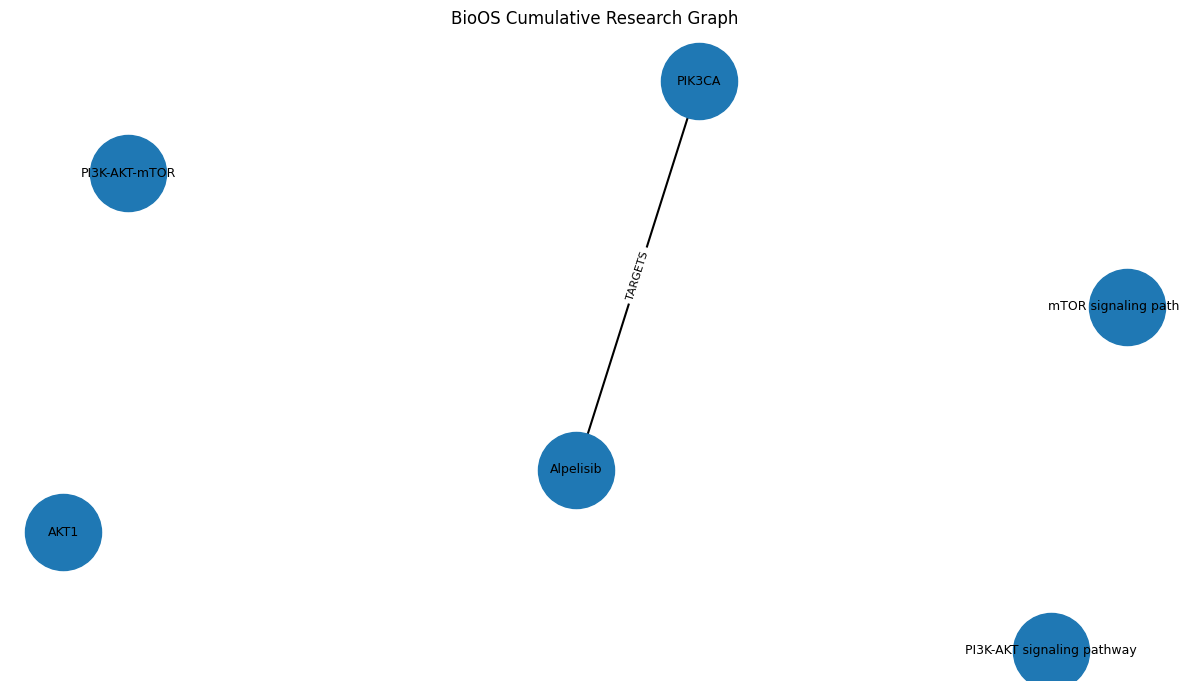

In [14]:
plt.figure(figsize=(12, 7))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

node_labels = {
    node_id: data["name"]
    for node_id, data in G.nodes(data=True)
}

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3000
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=node_labels,
    font_size=9
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    width=1.5
)

edge_labels = {
    (source, target): data["relationship"]
    for source, target, data in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("BioOS Cumulative Research Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
total_mentions = sum(
    len(row["objects"])
    for _, row in extractions_df.iterrows()
)

unique_objects = len(graph_nodes)

reused_mentions = total_mentions - unique_objects

print(f"Imported excerpts:       {len(extractions_df)}")
print(f"Total object mentions:   {total_mentions}")
print(f"Unique persistent nodes: {unique_objects}")
print(f"Reused object mentions:  {reused_mentions}")
print(f"Persistent edges:        {len(graph_edges)}")

Imported excerpts:       5
Total object mentions:   7
Unique persistent nodes: 6
Reused object mentions:  1
Persistent edges:        1


### Graph accumulation

Five independent excerpts produced seven biomedical object mentions.
After entity resolution, these mentions corresponded to six unique
persistent research objects.

PIK3CA was independently extracted from both P01 and P02 and was therefore
merged into a single persistent node while retaining both excerpts as
provenance.

This demonstrates an important distinction between independent document
extraction and persistent research representation: repeated concepts do
not need to remain isolated within the documents in which they were
originally encountered.

The graph remains sparse because the baseline extractor produced relatively
few relationships. This is consistent with the extraction limitations
identified in Notebook 01 and illustrates how upstream extraction recall
directly affects downstream graph connectivity.

In [16]:
ask_nodes = [
    {
        "id": node["id"],
        "type": node["type"],
        "name": node["name"],
        "summary": node["summary"]
    }
    for node in graph_nodes
]

ask_edges = [
    {
        "id": edge["id"],
        "source": edge["source"],
        "target": edge["target"],
        "type": edge["relationship"]
    }
    for edge in graph_edges
]

print(f"QA nodes: {len(ask_nodes)}")
print(f"QA edges: {len(ask_edges)}")

QA nodes: 6
QA edges: 1


In [17]:
pik3ca_node = next(
    node
    for node in ask_nodes
    if node["name"].lower() == "pik3ca"
)

pik3ca_node

{'id': 'n1',
 'type': 'Gene',
 'name': 'PIK3CA',
 'summary': 'Mutations in PIK3CA are commonly found in breast cancer.'}

## Graph-Grounded Question Answering

The accumulated graph can now be passed to BioOS's question-answering
pipeline.

PIK3CA is selected as the focal research object. BioOS receives the
persistent graph state rather than the original excerpts, allowing the
answer to be generated from structured knowledge accumulated across
multiple imports.

In [18]:
ASK_URL = f"{API_BASE}/api/ask"

question = "What drug in the research graph targets PIK3CA?"

payload = {
    "question": question,
    "nodes": ask_nodes,
    "edges": ask_edges,
    "selected_node_id": pik3ca_node["id"]
}

start = time.time()

response = requests.post(
    ASK_URL,
    json=payload,
    timeout=120
)

response.raise_for_status()

qa_result = response.json()
qa_latency = time.time() - start

print("Question:")
print(question)

print("\nBioOS answer:")
print(qa_result["answer"])

print("\nReferenced objects:")
print(qa_result["referenced"])

print(f"\nLatency: {qa_latency:.2f}s")

Question:
What drug in the research graph targets PIK3CA?

BioOS answer:
The research graph indicates that [[Alpelisib]] targets [[PIK3CA]].

Referenced objects:
['Alpelisib', 'PIK3CA']

Latency: 27.78s


In [19]:
graph_object_names = {
    node["name"]
    for node in ask_nodes
}

referenced_objects = set(
    qa_result.get("referenced", [])
)

unknown_references = (
    referenced_objects - graph_object_names
)

grounded = len(unknown_references) == 0

print("All referenced objects exist in graph:", grounded)

if unknown_references:
    print("Unknown references:", unknown_references)

All referenced objects exist in graph: True


## Conclusion

This demonstration followed the complete BioOS research workflow:

**Scientific excerpts → structured extraction → entity resolution → persistent graph → graph-grounded question answering**

Five independently processed excerpts produced biomedical objects that
were accumulated into a shared research representation. Repeated mentions
of PIK3CA across separate excerpts were resolved to the same persistent
node while retaining source provenance.

The resulting graph was then used as structured context for question
answering. BioOS identified Alpelisib as targeting PIK3CA using the
relationship stored in the accumulated graph, and the referenced objects
could be verified against the graph state.

The demonstration also exposes an important current limitation. The graph
is relatively sparse because several entities and relationships were not
recovered by the baseline extraction model. As shown quantitatively in
`01_bioos_evaluation.ipynb`, extraction recall—particularly for Disease
and Pathway objects—remains a major constraint on graph completeness.

Together, the two notebooks therefore demonstrate both sides of the
prototype:

- `01_bioos_evaluation.ipynb` evaluates where the extraction pipeline
  succeeds and fails.
- `02_research_graph_demo.ipynb` demonstrates how extracted knowledge can
  persist, accumulate, retain provenance, and support grounded retrieval
  across multiple research excerpts.